In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_excel("Sample - Superstore.xlsx")
df

In [2]:
print(df.shape)

(9994, 21)


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [4]:
df.info

<bound method DataFrame.info of       Row ID        Order ID Order Date  Ship Date       Ship Mode  \
0          1  CA-2020-152156 2020-11-08 2020-11-11    Second Class   
1          2  CA-2020-152156 2020-11-08 2020-11-11    Second Class   
2          3  CA-2020-138688 2020-06-12 2020-06-16    Second Class   
3          4  US-2019-108966 2019-10-11 2019-10-18  Standard Class   
4          5  US-2019-108966 2019-10-11 2019-10-18  Standard Class   
...      ...             ...        ...        ...             ...   
9989    9990  CA-2018-110422 2018-01-21 2018-01-23    Second Class   
9990    9991  CA-2021-121258 2021-02-26 2021-03-03  Standard Class   
9991    9992  CA-2021-121258 2021-02-26 2021-03-03  Standard Class   
9992    9993  CA-2021-121258 2021-02-26 2021-03-03  Standard Class   
9993    9994  CA-2021-119914 2021-05-04 2021-05-09    Second Class   

     Customer ID     Customer Name    Segment Country/Region             City  \
0       CG-12520       Claire Gute   Consumer 

In [5]:
df.describe

<bound method NDFrame.describe of       Row ID        Order ID Order Date  Ship Date       Ship Mode  \
0          1  CA-2020-152156 2020-11-08 2020-11-11    Second Class   
1          2  CA-2020-152156 2020-11-08 2020-11-11    Second Class   
2          3  CA-2020-138688 2020-06-12 2020-06-16    Second Class   
3          4  US-2019-108966 2019-10-11 2019-10-18  Standard Class   
4          5  US-2019-108966 2019-10-11 2019-10-18  Standard Class   
...      ...             ...        ...        ...             ...   
9989    9990  CA-2018-110422 2018-01-21 2018-01-23    Second Class   
9990    9991  CA-2021-121258 2021-02-26 2021-03-03  Standard Class   
9991    9992  CA-2021-121258 2021-02-26 2021-03-03  Standard Class   
9992    9993  CA-2021-121258 2021-02-26 2021-03-03  Standard Class   
9993    9994  CA-2021-119914 2021-05-04 2021-05-09    Second Class   

     Customer ID     Customer Name    Segment Country/Region             City  \
0       CG-12520       Claire Gute   Consume

# Check the missing values

In [6]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            3
Country/Region     0
City               0
State              4
Postal Code       22
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales             12
Quantity           1
Discount           0
Profit             5
dtype: int64

In [7]:
missing_percent = (df.isnull().sum()/len(df))*100
print(missing_percent)

Row ID            0.000000
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Ship Mode         0.000000
Customer ID       0.000000
Customer Name     0.000000
Segment           0.030018
Country/Region    0.000000
City              0.000000
State             0.040024
Postal Code       0.220132
Region            0.000000
Product ID        0.000000
Category          0.000000
Sub-Category      0.000000
Product Name      0.000000
Sales             0.120072
Quantity          0.010006
Discount          0.000000
Profit            0.050030
dtype: float64


In [8]:
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Postal Code              float64
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                     object
Quantity                 float64
Discount                 float64
Profit                   float64
dtype: object

# Handling the Missing values

In [9]:
df['Segment']= df['Segment'].fillna(df['Segment'].mode()[0])
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              4
Postal Code       22
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales             12
Quantity           1
Discount           0
Profit             5
dtype: int64

In [10]:
df["State"].dtypes

dtype('O')

In [11]:
df['State'] = df['State'].fillna(df['State'].mode()[0])

In [12]:
df['Postal Code'].dtypes

dtype('float64')

In [13]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].median())

In [14]:
df['Sales']=df['Sales'].fillna(df['Sales'].median())

TypeError: could not convert string to float: '$261.96'

In [15]:
# filter the special charcter columns
df[df['Sales'].str.contains(r'[A-Za-z 0-9/s]',na=False)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,$261.96,2.0,0.0,41.9136
115,116,CA-2018-115259,2018-08-25,2018-08-27,Second Class,RC-19960,Ryan Crowe,Consumer,United States,Columbus,...,43229.0,East,OFF-PA-10004965,Office Supplies,Paper,Xerox 1921,$23.976,3.0,0.2,7.4925
165,166,CA-2018-139892,2018-09-08,2018-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,78207.0,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,$8159.952,8.0,0.4,-1359.9920


In [16]:
df['Sales']=pd.to_numeric(df['Sales'],errors='coerce')

In [17]:
df['Sales'].dtypes

dtype('float64')

In [18]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales             15
Quantity           1
Discount           0
Profit             5
dtype: int64

In [20]:
df["Sales"]=df['Sales'].fillna(df['Sales'].mean())
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          1
Discount          0
Profit            5
sales             0
dtype: int64

In [21]:
df['Quantity'].dtypes

dtype('float64')

In [22]:
df['Quantity']=df['Quantity'].fillna(df['Quantity'].median())

In [23]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            5
sales             0
dtype: int64

In [26]:
df['Profit']=df['Profit'].fillna(df['Profit'].median())
df.isnull().sum()
                                 

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
sales             0
profit            0
dtype: int64

# Exploratory Data Analysis(EDA)

In [27]:
# Total Sales

df['Sales'].sum()

2291282.8629870927

In [28]:
# Total profit
df['Profit'].sum()

285763.93669999996

In [31]:
# Top 10 product sales
top_products=df.groupby("Product Name")['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [32]:
# Top Categories
df.groupby('Category')['Sales'].sum()

Category
Furniture          742331.773375
Office Supplies    720510.468921
Technology         828440.620692
Name: Sales, dtype: float64

In [33]:
# Sales by region
df.groupby('Region')["Sales"].sum()

Region
Central    493802.163029
East       679588.369383
South      391911.258692
West       725981.071883
Name: Sales, dtype: float64

# Visualization
sales by Category

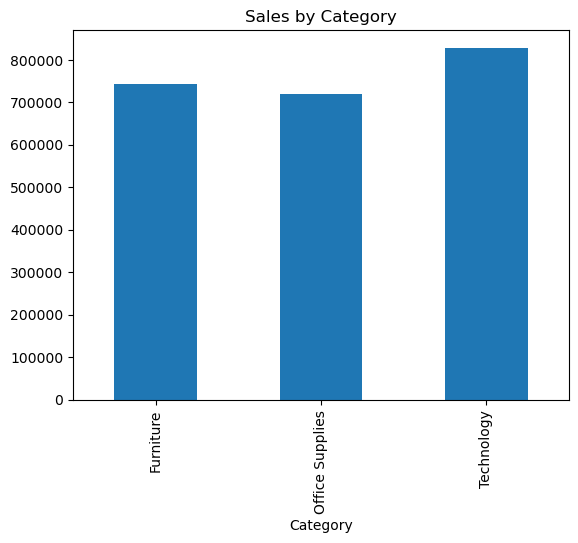

In [34]:
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.show()

profit by region

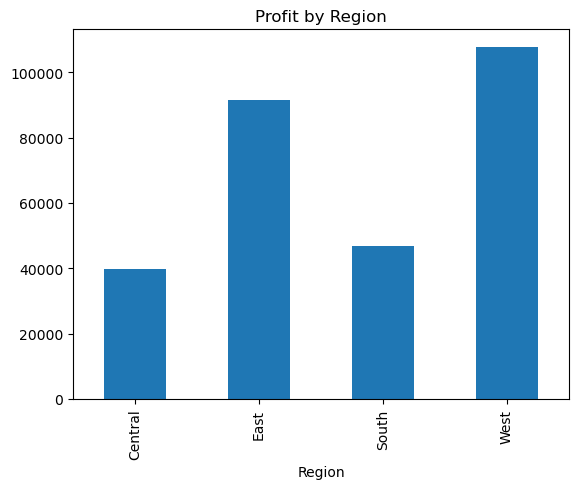

In [35]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')

plt.title("Profit by Region")
plt.show()

Monthly sales trend

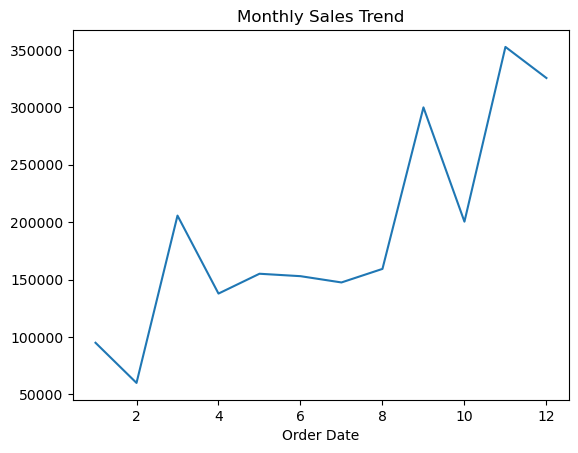

In [36]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

# Business Insights

1. Technology category generated the highest sales.
2. West region generated maximum profit.
3. Sales peaked during November and December.

In [39]:
!pip install openpyxl

In [40]:
df.to_excel("Superstore_Cleaned.xlsx", index=False)

In [41]:
import os

print(os.listdir())

['.anaconda', '.arduinoIDE', '.avatarify', '.cache', '.conda', '.continuum', '.copilot', '.eclipse', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.keras', '.Ld9VirtualBox', '.matplotlib', '.ms-ad', '.opera', '.p2', '.vscode', '.vscode-shared', 'Add.class', 'add.java', 'addition.java', 'addition.java.bak', 'AkVirtualCamera.plugin', 'anaconda3', 'Analysis project.ipynb', 'AppData', 'Application Data', 'avatarify', 'Contacts', 'Cookies', 'decision tree continuous.ipynb', 'Decision Tree ML 3 model..ipynb', 'Desktop', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'environment.yml', 'Favorites', 'height_weight.csv', 'house_pricing_data.csv', 'html', 'IntelGraphicsProfiles', 'linear Regression ML .ipynb', 'Links', 'Loan Delinquent Dataset.csv', 'Local Settings', 'logistic regression ml 2 molde.ipynb', 'Microsoft', 'miniconda3', 'Ml 1st module.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc